In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline 

In [2]:
data=pd.read_csv(r"C:\Users\Amin\Downloads\kc_house_data.csv") 
df=data.copy()
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [4]:
#changing dtype with pandas 
df['date']=pd.to_datetime(df['date']) 

In [6]:
#checking duplicated 
subset_list=df.drop("date", axis=1)
df.duplicated(subset=subset_list).sum() 
df.drop_duplicates(subset=subset_list, inplace=True)

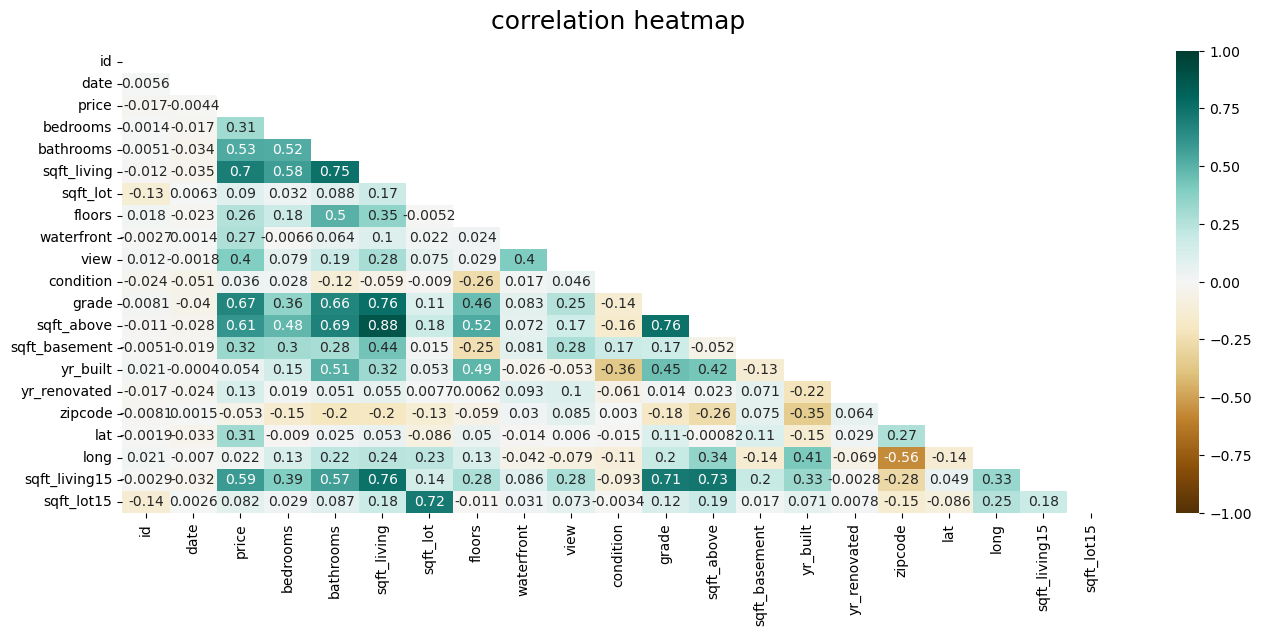

In [7]:
plt.figure(figsize=(16,6)) 
mask=np.triu(np.ones_like(df.corr(), dtype=bool)) 
heatmap=sns.heatmap(df.corr(), mask=mask,vmin=-1,vmax=1,annot=True, cmap='BrBG') 
heatmap.set_title('correlation heatmap', fontdict={'fontsize':18},pad=16);

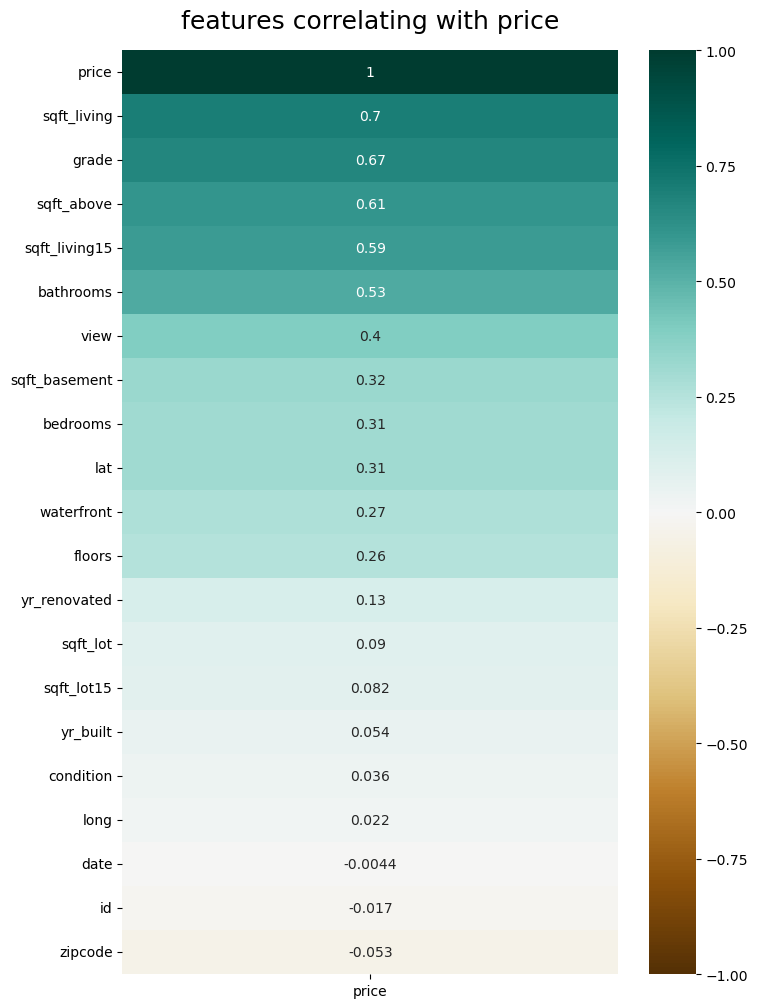

In [8]:
plt.figure(figsize=(8, 12))
heatmap = sns.heatmap(df.corr()[['price']].sort_values(by='price', ascending=False), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('features correlating with price', fontdict={'fontsize':18}, pad=16);

In [9]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [10]:
df.drop(["lat","long","date"], axis=1,inplace=True) 

In [11]:
y=df[["price"]] 
x=df.drop("price",axis=1) 

In [12]:
from sklearn.preprocessing import MinMaxScaler 
scaler=MinMaxScaler() 
x_cols=x.columns 
x_index=x.index 
x=scaler.fit_transform(x) 
x=pd.DataFrame(data=x, columns=x_cols, index=x_index)  
x.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,sqft_living15,sqft_lot15
0,0.720103,0.090909,0.12500,0.067170,0.003108,0.0,0.0,0.0,0.5,0.500000,0.097588,0.000000,0.478261,0.000000,0.893939,0.161934,0.005742
1,0.647853,0.090909,0.28125,0.172075,0.004072,0.4,0.0,0.0,0.5,0.500000,0.206140,0.082988,0.443478,0.988089,0.626263,0.222165,0.008027
2,0.568795,0.060606,0.12500,0.036226,0.005743,0.0,0.0,0.0,0.5,0.416667,0.052632,0.000000,0.286957,0.000000,0.136364,0.399415,0.008513
3,0.251157,0.121212,0.37500,0.126038,0.002714,0.0,0.0,0.0,1.0,0.500000,0.083333,0.188797,0.565217,0.000000,0.681818,0.165376,0.004996
4,0.197333,0.090909,0.25000,0.104906,0.004579,0.0,0.0,0.0,0.5,0.583333,0.152412,0.000000,0.756522,0.000000,0.368687,0.241094,0.007871


In [13]:
df.head(3)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,sqft_living15,sqft_lot15
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,1340,5650
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,1690,7639
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,2720,8062


In [14]:
num_cols = ["bathrooms","sqft_living","floors","sqft_above",
           "yr_built","zipcode","sqft_living15",] 

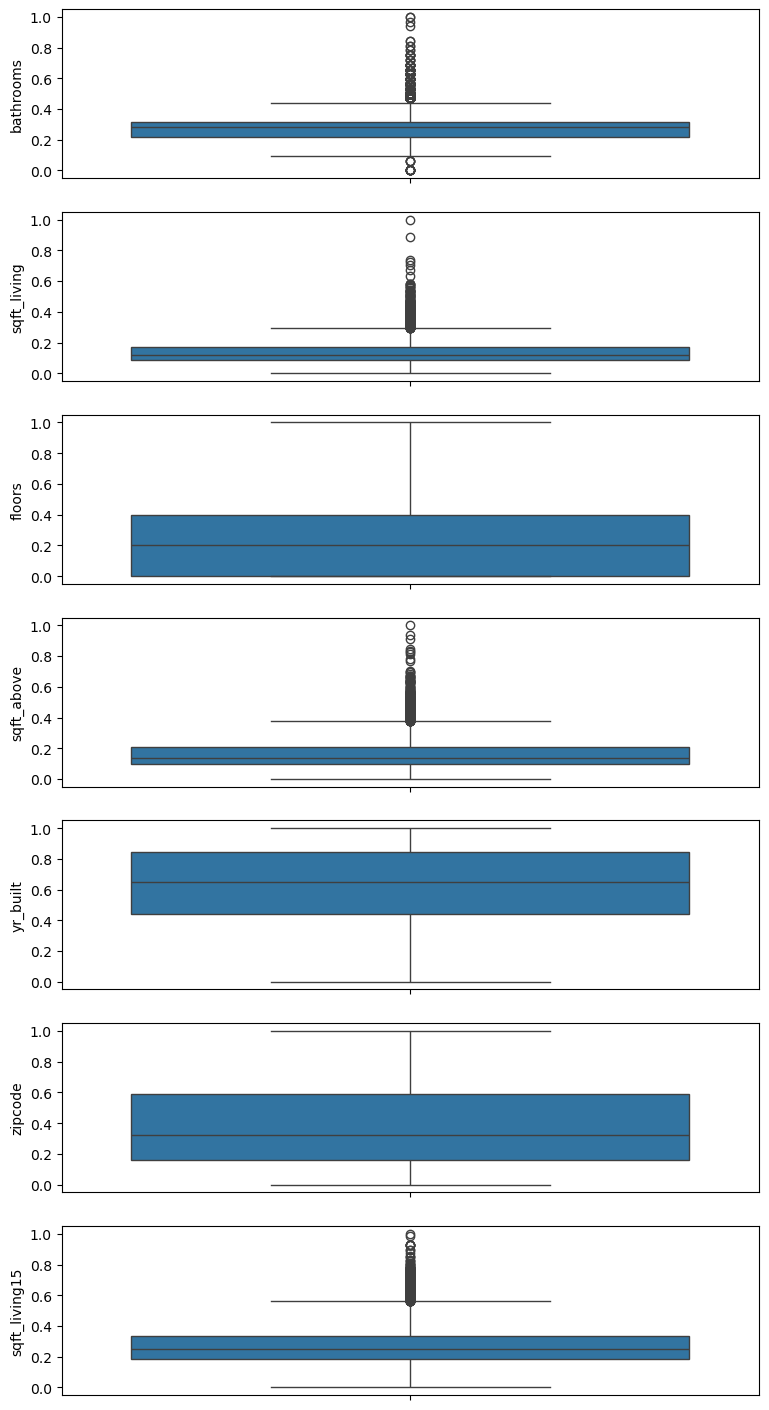

In [15]:
x_cols=num_cols 
fig, axes=plt.subplots(nrows=len(x_cols),figsize=(9,18)) 
for i in range(len(x_cols)): 
    sns.boxplot(ax=axes[i],y=x_cols[i],data=x) 

In [16]:
#treating outliers 
def outlier_detection(cols): 
    q1, q3= np.percentile(cols, [25,75]) 
    iqr=q3-q1 
    upper_bound=q3+(1.5*iqr) 
    lower_bound=q1-(1.5*iqr) 
    return upper_bound,lower_bound

In [17]:
for cols in x_cols: 
    upper_bound, lower_bound=outlier_detection(x[cols]) 
    x[cols]= np.clip(x[cols], a_min=lower_bound, a_max=upper_bound)

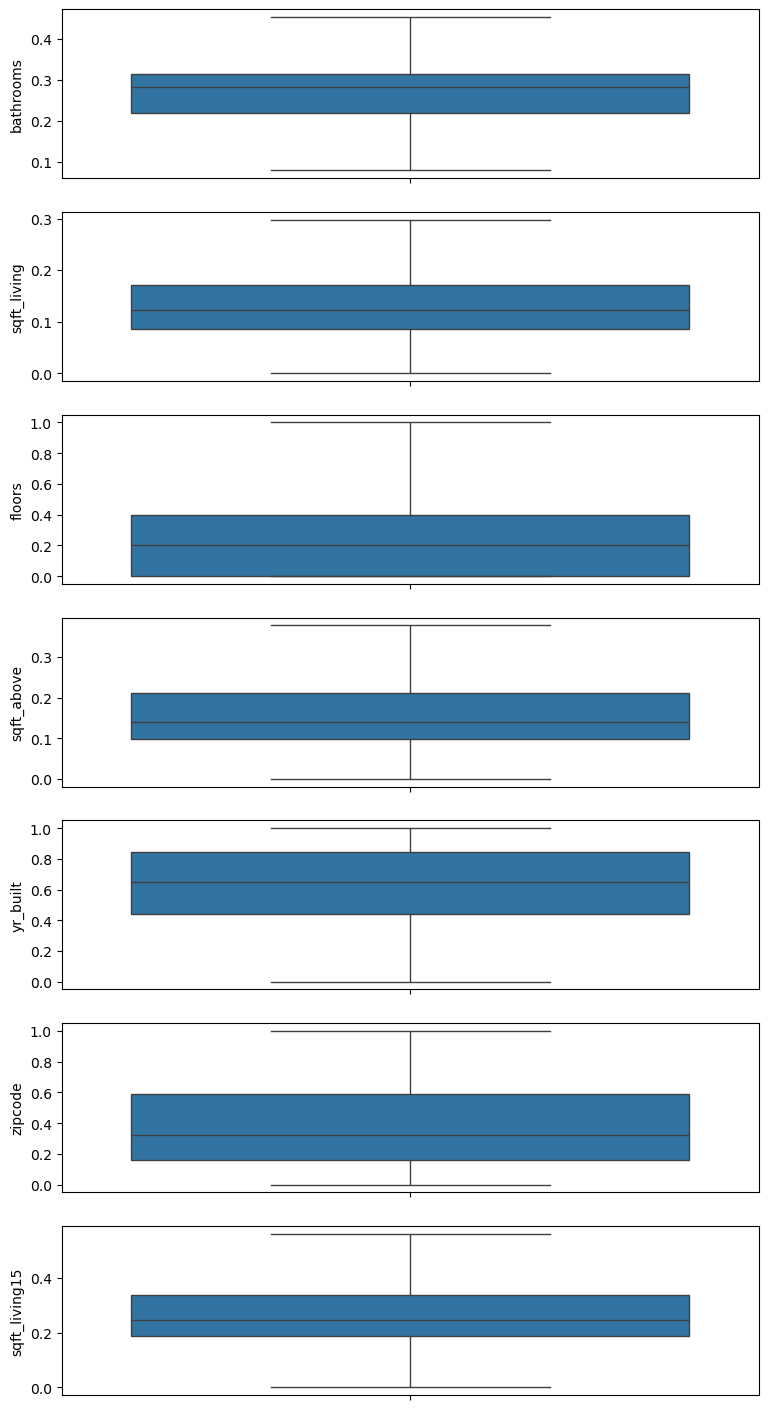

In [18]:
fig,axes=plt.subplots(nrows=len(num_cols), figsize=(9,18)) 
for i in range(len(num_cols)): 
    sns.boxplot(data=x, ax=axes[i], y=num_cols[i])